In [94]:
import pandas as pd
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\train.csv') 
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [95]:
df['Age']=df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [96]:
pa=df['Survived'].mean()## pa - вероятность выживания
pa

np.float64(0.3838383838383838)

In [76]:
df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
pb1a=df[df['Age'] <=25]['Survived'].mean() ## pb1a - вероятность выживания с возрастом до 25 лет
print(pb1a)
pb2a=df[(df['Age'] <= 50) & (df['Age'] >25)]['Survived'].mean()## pb2a - вероятность выживания с возрастом от 25 до 50 лет
print(pb2a)
pb3a=df[df['Age'] >50]['Survived'].mean()## pb2a - вероятность выживания с возрастом боллее 50 лет
print(pb3a)

0.36155606407322655
0.4153846153846154
0.34375


In [77]:
def usl_ver(pa,pba): ## фунция вычисляющая уловн вероятост по формуле P(AB)=P(A)P(B|A)
    return pa*pba

In [78]:
print(usl_ver(pa,pb1a))## Находим вероятность выживания для каждой группы
print(usl_ver(pa,pb2a))
print(usl_ver(pa,pb3a))

0.13877909530083443
0.15944055944055943
0.13194444444444445


In [79]:
a=df['Sex'].value_counts(normalize=True) ##% мужчин и женщин
a

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [80]:
pb=a.loc['female']## доля  женщин
pb

np.float64(0.35241301907968575)

In [81]:
pab=df[df['Sex'] == 'female']['Survived'].mean()## pab - вероятность выживания  женщины
pab

np.float64(0.7420382165605095)

In [82]:
## Применяем формулу Байеса

In [83]:
res = pab*pb/pa
res

np.float64(0.6812865497076023)

In [ ]:
##доп.решение задачи №1

In [85]:
df['Age_cat'] = pd.cut(df['Age'], [0, 25, 50, 100])

In [86]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_cat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,"(0, 25]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(25, 50]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(25, 50]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,"(25, 50]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,"(25, 50]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,"(25, 50]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,"(0, 25]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,NaN,S,"(0, 25]"
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,"(25, 50]"


In [90]:
gr=df.groupby(['Age_cat'],observed=True)[['Survived']].mean()
gr

,Survived
Age_cat,
"(0, 25]",0.361556
"(25, 50]",0.415385
"(50, 100]",0.343750


In [100]:
gr['res']=gr['Survived']*pa
gr

,Survived,res
Age_cat,,
"(0, 25]",0.361556,0.138779
"(25, 50]",0.415385,0.159441
"(50, 100]",0.343750,0.131944


In [130]:
import numpy as np
from scipy import integrate

# функция
def f(x):
    return l*np.exp(-l*x)
l=2
res= integrate.quad(f, 1, 2)
print(res)

(0.1170196443478785, 1.2991790348846178e-15)


λ = 0.1 Вероятность события в точке x0- (0.08610666495797772, 9.559760201003101e-16)
λ = 20.1 Вероятность события в точке x0- (1.86500891842451e-09, 3.088408520329835e-16)
λ = 40.1 Вероятность события в точке x0- (3.844069895287398e-18, 5.228200175005613e-20)
λ = 60.1 Вероятность события в точке x0- (7.92321864760138e-27, 9.868594578379905e-27)
λ = 80.1 Вероятность события в точке x0- (1.6330970697279937e-35, 2.1852541220591248e-37)


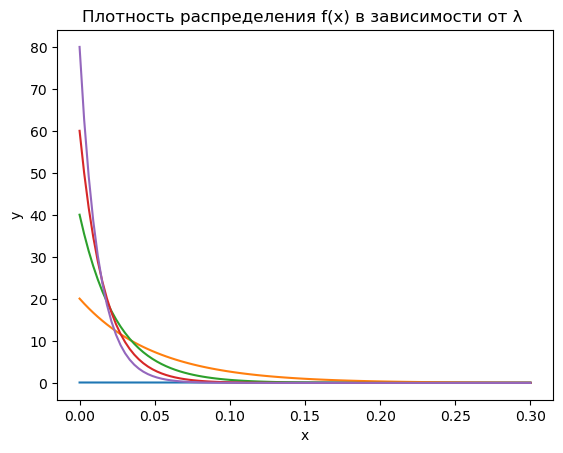

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
x=np.linspace(0, 0.3, 100)
l=np.arange(0.1,100,20) ## При экспотенциальном распределении  должно выполняться ограничение λ>0
plt.xlabel("x")
plt.ylabel("y")
plt.title("Плотность распределения f(x) в зависимости от λ ")
for c in l:
    y=c*np.exp(-c*x)
    plt.plot(x, y, label=c)
    def f(x):
        return c*np.exp(-c*x)
    integral= integrate.quad(f, 1, 2)
    print('λ =',c,end=' ')
    print('Вероятность события в точке x0-',integral)
## Полощадь всей фигуры  можно получить проинтегрировав функцию плотности вероятности (собственно получиф фунцию распределения F(x) = 1-e^(-λx)